# Midterm Assignment. Task 1: ## Preparation

## Configuration

Loading config:

In [46]:
import yaml
import os

# Load config
with open("../config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

data_path = os.path.join(cfg['paths']['data_dir'], cfg['files']['raw_data'])

Importing data:

In [47]:
import pandas as pd

# Import the raw data
data = pd.read_csv(data_path)

# Output the data
data.head()

# Select numerical columns
num_cols = [
    'age', 
    'university_year',
    'GPA', 
    'study_hours_per_day', 
    'class_attendance_percent', 
    'sleep_hours', 
    'screen_time_hours', 
    'social_media_hours', 
    'gaming_hours', 
    'exercise_hours_per_week', 
    'mental_stress_level', 
    'AI_tool_usage_hours', 
    'exam_preparation_days',
    'coffee_consumption_per_day', 
    'extracurricular_hours_per_week'
]

# Get columns for One-Hot encoding
cat_cols = [
    'gender',
    'country',
    'major',
    'relationship_status',
    'favorite_AI_tool',
    'note_taking_method'
]

## Graphs and data

Graph preparation

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Plot 1: Distribution of the Target Variable

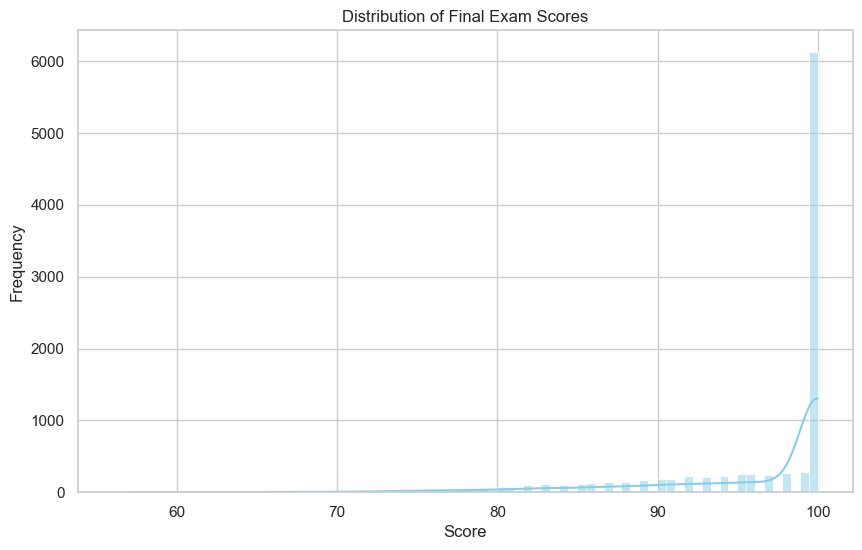

In [49]:
plt.figure()
sns.histplot(data['final_exam_score'], kde=True, color='skyblue')
plt.title('Distribution of Final Exam Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

Plot 2: Correlation Heatmap

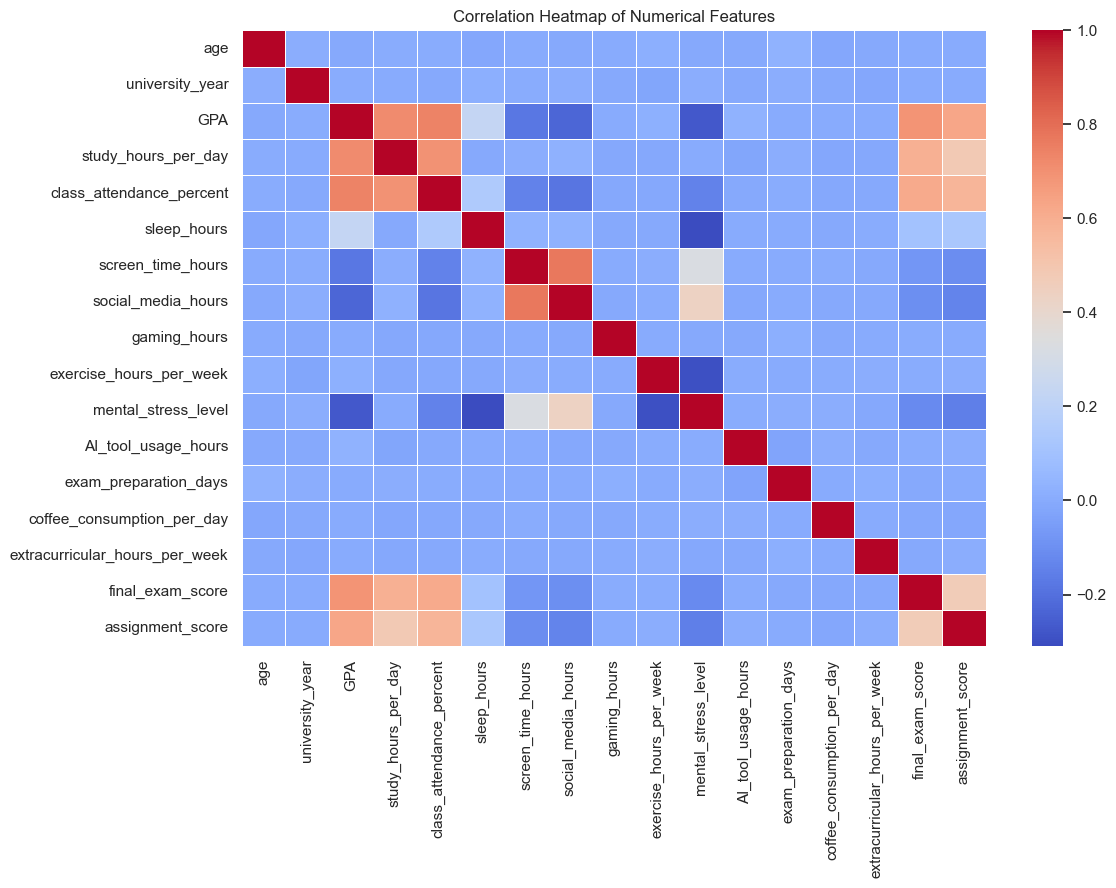

In [50]:
plt.figure(figsize=(12, 8))
# Only correlate numerical columns to keep it clean
corr_matrix = data[num_cols + ['final_exam_score', 'assignment_score']].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Plot 3: GPA by Major (Boxplot)

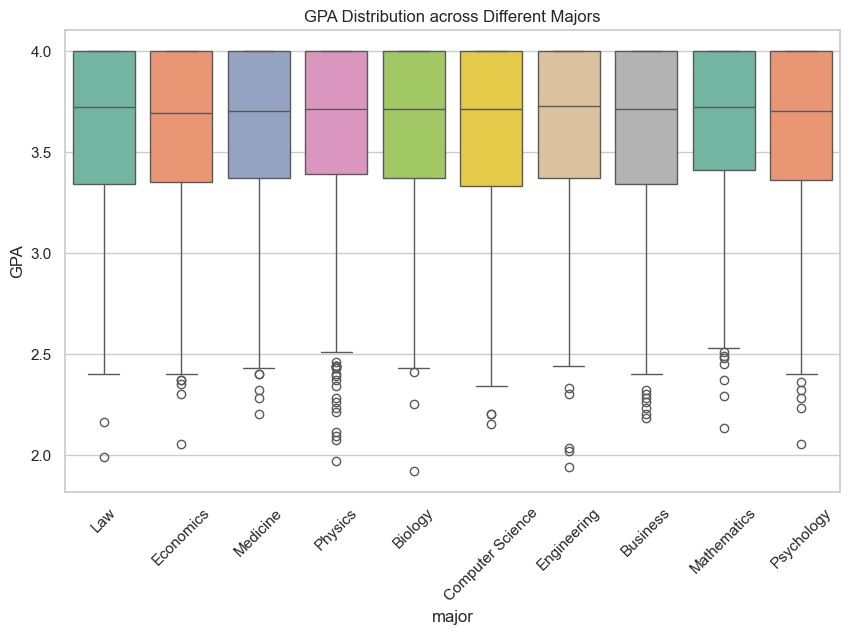

In [51]:
plt.figure()
sns.boxplot(data=data, x='major', hue='major', y='GPA', palette='Set2', legend=False)
plt.xticks(rotation=45)
plt.title('GPA Distribution across Different Majors')
plt.show()

Plot 4: Study Hours vs Mental Stress

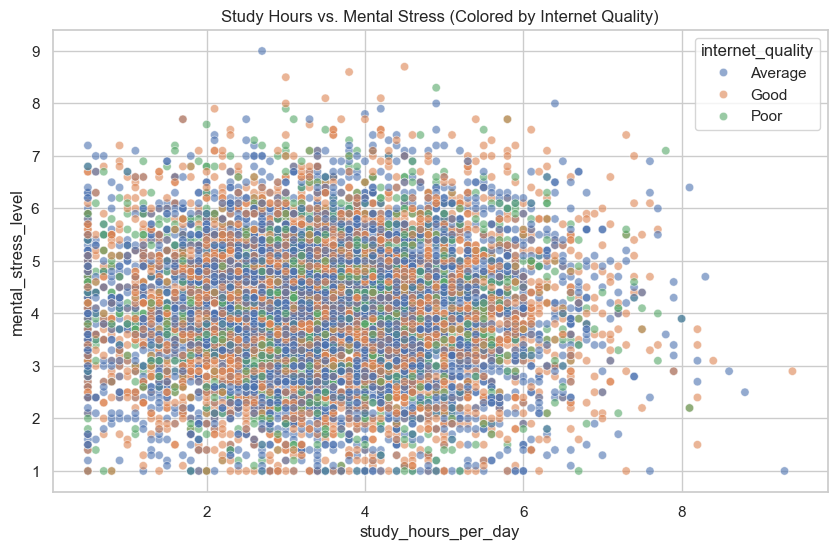

In [52]:
plt.figure()
sns.scatterplot(data=data, x='study_hours_per_day', y='mental_stress_level', 
                hue='internet_quality', alpha=0.6)
plt.title('Study Hours vs. Mental Stress (Colored by Internet Quality)')
plt.show()

Plot 5: AI Tool Usage vs Final Score

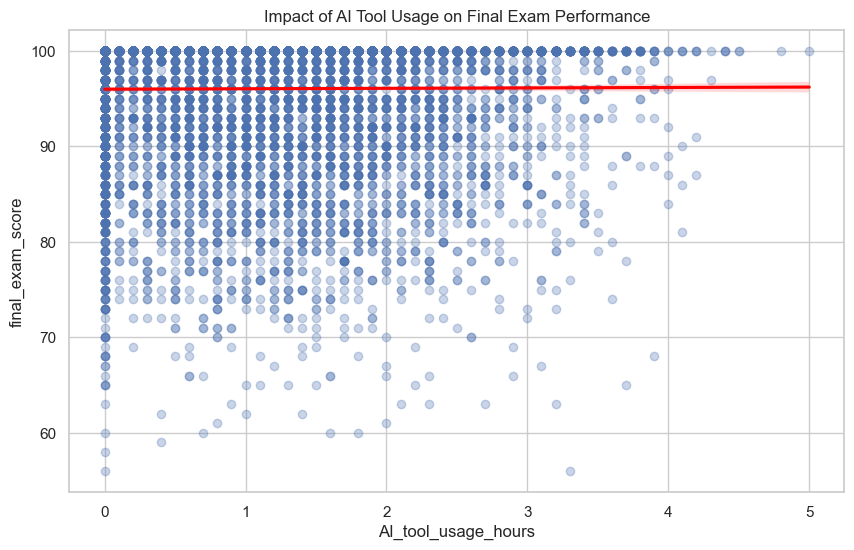

In [53]:
plt.figure()
sns.regplot(data=data, x='AI_tool_usage_hours', y='final_exam_score', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Impact of AI Tool Usage on Final Exam Performance')
plt.show()

## Handling data

#### Dealing with NaNs

In [54]:
from sklearn.impute import SimpleImputer
import joblib

# Fill numerical NaNs with the Median
imputer_num = SimpleImputer(strategy='median')
data[num_cols] = imputer_num.fit_transform(data[num_cols])

# Save for predict.py
joblib.dump(imputer_num, f"{cfg['paths']['model_dir']}imputer.joblib")

['../models/imputer.joblib']

#### Handling numerical data (normalization)

In [55]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

# Save for predict.py
joblib.dump(scaler, f"{cfg['paths']['model_dir']}scaler.joblib")

data.head()

,student_id,age,gender,country,major,university_year,GPA,study_hours_per_day,class_attendance_percent,sleep_hours,...,internet_quality,mental_stress_level,AI_tool_usage_hours,favorite_AI_tool,note_taking_method,exam_preparation_days,coffee_consumption_per_day,extracurricular_hours_per_week,final_exam_score,assignment_score
0,S00001,0.014845,Female,Germany,Law,1.325907,0.487020,0.468386,0.553797,-0.683002,...,Average,0.583235,0.269352,Claude,Digital,0.596258,0.897705,1.848175,100,100
1,S00002,0.964426,Female,USA,Economics,-0.454073,-0.398862,-0.142083,0.352840,-0.347308,...,Average,-0.121637,1.148941,Gemini,Mixed,-0.210832,0.897705,0.609144,100,83
2,S00003,-1.567790,Female,Canada,Medicine,0.435917,0.967928,0.671876,0.955711,-0.599078,...,Average,0.583235,-1.379877,NaN,Mixed,-0.009060,0.897705,0.299386,100,100
3,S00004,-0.934736,Male,Australia,Physics,1.325907,0.385777,1.553664,0.654276,0.072308,...,Good,1.444745,1.808633,Gemini,Mixed,-0.210832,-0.595484,-0.010372,100,98
4,S00005,1.597480,Female,Australia,Medicine,-0.454073,0.967928,-0.277743,0.553797,1.163312,...,Good,-0.748190,0.269352,ChatGPT,Handwritten,0.596258,1.644299,-1.352656,100,94


The normalization of numerical data for better results

Defining mappings for Ordinal values:

In [56]:
# Mapping dictionaries
income_map = {'Low': 0, 'Middle': 1, 'High': 2}
internet_map = {'Poor': 0, 'Average': 1, 'Good': 2}

# Apply mappings
data['family_income_level'] = data['family_income_level'].map(income_map)
data['internet_quality'] = data['internet_quality'].map(internet_map)

# Use 0/1 for part_time_job
data['part_time_job'] = data['part_time_job'].map({'No': 0, 'Yes': 1})

data.head()

,student_id,age,gender,country,major,university_year,GPA,study_hours_per_day,class_attendance_percent,sleep_hours,...,internet_quality,mental_stress_level,AI_tool_usage_hours,favorite_AI_tool,note_taking_method,exam_preparation_days,coffee_consumption_per_day,extracurricular_hours_per_week,final_exam_score,assignment_score
0,S00001,0.014845,Female,Germany,Law,1.325907,0.487020,0.468386,0.553797,-0.683002,...,1,0.583235,0.269352,Claude,Digital,0.596258,0.897705,1.848175,100,100
1,S00002,0.964426,Female,USA,Economics,-0.454073,-0.398862,-0.142083,0.352840,-0.347308,...,1,-0.121637,1.148941,Gemini,Mixed,-0.210832,0.897705,0.609144,100,83
2,S00003,-1.567790,Female,Canada,Medicine,0.435917,0.967928,0.671876,0.955711,-0.599078,...,1,0.583235,-1.379877,NaN,Mixed,-0.009060,0.897705,0.299386,100,100
3,S00004,-0.934736,Male,Australia,Physics,1.325907,0.385777,1.553664,0.654276,0.072308,...,2,1.444745,1.808633,Gemini,Mixed,-0.210832,-0.595484,-0.010372,100,98
4,S00005,1.597480,Female,Australia,Medicine,-0.454073,0.967928,-0.277743,0.553797,1.163312,...,2,-0.748190,0.269352,ChatGPT,Handwritten,0.596258,1.644299,-1.352656,100,94


Save mappings for predict.py

In [57]:
import joblib

# Bundle the maps into a dictionary
encoding_maps = {
    'family_income_level': income_map,
    'internet_quality': internet_map,
    'part_time_job': {'No': 0, 'Yes': 1}
}

# Save to your models directory
joblib.dump(encoding_maps, f"{cfg['paths']['model_dir']}encoding_maps.joblib")

['../models/encoding_maps.joblib']

#### Managing Non-Numerical data

In [58]:
# One-Hot Encoding for non-ordered categories with drop_first
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

data.head()

,student_id,age,university_year,GPA,study_hours_per_day,class_attendance_percent,sleep_hours,screen_time_hours,social_media_hours,gaming_hours,...,major_Mathematics,major_Medicine,major_Physics,major_Psychology,relationship_status_Single,favorite_AI_tool_Claude,favorite_AI_tool_Copilot,favorite_AI_tool_Gemini,note_taking_method_Handwritten,note_taking_method_Mixed
0,S00001,0.014845,1.325907,0.487020,0.468386,0.553797,-0.683002,-1.004347,0.346405,-1.358379,...,False,False,False,False,True,True,False,False,False,False
1,S00002,0.964426,-0.454073,-0.398862,-0.142083,0.352840,-0.347308,-0.473084,0.277451,0.962622,...,False,False,False,False,True,False,False,True,False,True
2,S00003,-1.567790,0.435917,0.967928,0.671876,0.955711,-0.599078,-1.110599,-0.963723,-1.358379,...,False,True,False,False,False,False,False,False,False,True
3,S00004,-0.934736,1.325907,0.385777,1.553664,0.654276,0.072308,0.589441,0.622221,0.446844,...,False,False,True,False,True,False,False,True,False,True
4,S00005,1.597480,-0.454073,0.967928,-0.277743,0.553797,1.163312,-0.526210,-1.515356,-1.358379,...,False,True,False,False,False,False,False,False,True,False


## Preporation for ML

In [59]:
# Removing the student_id
data.drop(columns=['student_id'], inplace=True)

# Checking the whole table
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             10000 non-null  float64
 1   university_year                 10000 non-null  float64
 2   GPA                             10000 non-null  float64
 3   study_hours_per_day             10000 non-null  float64
 4   class_attendance_percent        10000 non-null  float64
 5   sleep_hours                     10000 non-null  float64
 6   screen_time_hours               10000 non-null  float64
 7   social_media_hours              10000 non-null  float64
 8   gaming_hours                    10000 non-null  float64
 9   exercise_hours_per_week         10000 non-null  float64
 10  part_time_job                   10000 non-null  int64  
 11  family_income_level             10000 non-null  int64  
 12  internet_quality                10000 non-nu

In resulting table, there shouldn't be any `object` columns and the total number of rows should be the same

In [60]:

data.to_csv(os.path.join(cfg['paths']['data_dir'], 'cleaned.csv'), index=False)

## Data Analysis Summary

The exploratory analysis of the student performance dataset reveals significant insights into the behavioral drivers of academic success. A primary observation from the Distribution of Final Exam Scores is a pronounced ceiling effect, with a heavy bias toward a score of 100. This suggests a potential lack of granularity in the high-performance range or an exceptionally high achievement rate within the sampled cohort.

Correlation analysis via the Numerical Features Heatmap identifies GPA, study_hours_per_day, and attendance_percent as the most critical positive predictors of final grades. Conversely, a clear inverse correlation exists between academic performance and lifestyle factors such as screen_time_hours, social_media_hours, and mental_stress_level. This implies that excessive digital engagement and psychological strain act as primary inhibitors to high scores.

Interestingly, the relationship between study hours and mental stress remains remarkably neutral in the scatter plot, showing no definitive correlation and suggesting that stress levels are influenced by factors outside of purely academic volume. Finally, the AI Tool Usage regression analysis shows only a faint positive correlation with final scores, indicating that while these tools are integrated into student workflows, they do not yet serve as a dominant substitute for traditional study habits. These findings will guide the feature selection for the upcoming regression models to focus on high-impact behavioral variables.